# NOTEBOOK 04 — Procesamiento de Listas
**Curso:** Fundamentos de Python | **Semana:** 07  
**Docente:** Andrés Mena Abarca | **Universidad:** UMCA

**Estudiante:** Jairon Martínez Coronado

---

## ¿Qué trabajamos hoy?

En esta sesión profundizamos en el procesamiento de listas usando técnicas que complementan lo visto en S06.  
El dataset que utilizamos a lo largo de toda la clase son **temperaturas diarias de ciudades de Costa Rica**.



---
## Fase 0 — Repaso S06: Operaciones destructivas vs no-destructivas

En S06 aprendimos `sort()`, `append()`, `remove()` y `pop()`.  
Hoy partimos de un concepto clave que nos prepara para `sorted()`:  

**¿La operación modifica la lista original, o devuelve una nueva lista?**

- **Destructiva** → modifica la lista *in-place* (la lista original cambia).
- **No-destructiva** → devuelve una nueva lista; la original se conserva intacta.

In [ ]:
# ── Ejemplo: sort() es DESTRUCTIVO ──────────────────────────────────────────
notas = [85, 62, 91, 74]
print("Antes de sort():", notas)
notas.sort()
print("Después de sort():", notas)   # ← la lista original cambió

print()

# ── Ejemplo: sorted() es NO-DESTRUCTIVO ─────────────────────────────────────
temperaturas = [22, 35, 29, 31]
print("Antes de sorted():", temperaturas)
ordenadas = sorted(temperaturas)
print("Lista ordenada (nueva):", ordenadas)
print("Lista original intacta:", temperaturas)  # ← no cambió

### Ejercicio 0.1 — Exploramos la lista de temperaturas

Trabajamos con la siguiente lista de temperaturas registradas esta semana en San José:

```python
temperaturas_sj = [24, 19, 27, 22, 30, 18, 25]
```

Completamos las siguientes tareas:

1. Obtenemos las primeras **3 temperaturas** usando slicing.
2. Verificamos si **28** está en la lista con el operador `in`.
3. Calculamos el **promedio** sumando todos los valores y dividiendo entre el total.

In [16]:
temperaturas_sj = [24, 19, 27, 22, 30, 18, 25]
suma = 0
# Respuesta
temperaturas_sj.sort()
print(f"Primeras temperaturas básicas: {temperaturas_sj[0:3]}")

temperatura = 28 in temperaturas_sj
print(f"28 esta en temperaruras_sj: {temperatura}")

promedio = sum(temperaturas_sj) / len(temperaturas_sj)
print(f"Promedio: {promedio:.2f} C°")



Primeras temperaturas básicas: [18, 19, 22]
28 esta en temperaruras_sj: False
Promedio: 23.57 C°


---
## Fase 1 — `sorted()` con `key=` y slicing avanzado

### `sorted()` — ordenamiento no-destructivo con criterio personalizado

`sorted()` acepta el parámetro `key=` para definir **cómo se comparan** los elementos.  
Podemos pasar cualquier función como criterio: `len`, `str.lower`, o una función propia.

```python
sorted(iterable, key=función, reverse=False)
```

### Slicing avanzado

La sintaxis completa del slicing es `lista[inicio:fin:paso]`.  
Con índices negativos accedemos desde el final de la lista.

In [17]:
# ── sorted() con key= ────────────────────────────────────────────────────────
ciudades = ["Limón", "San José", "Liberia", "Puntarenas"]

# Ordenamos por número de letras (longitud de la cadena)
por_longitud = sorted(ciudades, key=len)
print("Por longitud (menor a mayor):", por_longitud)

# Ordenamos por longitud de forma inversa
por_longitud_inv = sorted(ciudades, key=len, reverse=True)
print("Por longitud (mayor a menor):", por_longitud_inv)

# Ordenamos alfabéticamente (comportamiento por defecto)
alfabetico = sorted(ciudades)
print("Alfabético:", alfabetico)

# Verificamos que la lista original no cambió
print("Original intacta:", ciudades)

Por longitud (menor a mayor): ['Limón', 'Liberia', 'San José', 'Puntarenas']
Por longitud (mayor a menor): ['Puntarenas', 'San José', 'Liberia', 'Limón']
Alfabético: ['Liberia', 'Limón', 'Puntarenas', 'San José']
Original intacta: ['Limón', 'San José', 'Liberia', 'Puntarenas']


In [18]:
# ── Slicing avanzado ─────────────────────────────────────────────────────────
temperaturas = [22, 35, 29, 31, 28, 33, 19]

ultimas_3  = temperaturas[-3:]    # las últimas 3 temperaturas
cada_dos   = temperaturas[::2]    # cada segundo elemento (índices 0, 2, 4, 6)
invertidas = temperaturas[::-1]   # invertimos la lista sin modificarla

print("Lista completa:  ", temperaturas)
print("Últimas 3:       ", ultimas_3)
print("Cada dos:        ", cada_dos)
print("Invertida:       ", invertidas)

Lista completa:   [22, 35, 29, 31, 28, 33, 19]
Últimas 3:        [28, 33, 19]
Cada dos:         [22, 29, 28, 19]
Invertida:        [19, 33, 28, 31, 29, 35, 22]


### Ejercicio 1.1 — Ranking de notas con `sorted()` y slicing

Trabajamos con las notas del grupo:

```python
notas = [85, 62, 91, 74, 58, 88]
```

Completamos las siguientes tareas:

1. Ordenamos con `sorted()` de menor a mayor y verificamos que `notas` **no cambió**.
2. Obtenemos el **Top 3** (las tres más altas) usando slicing `[-3:]` sobre la lista ordenada.
3. Obtenemos el ranking **de mayor a menor** usando `reverse=True`.

In [ ]:
notas = [85, 62, 91, 74, 58, 88]

# Respuesta
#1. Ordenamos con `sorted()` de menor a mayor y verificamos que `notas` **no cambió**.
ordenar = sorted(notas)
print(f"Orden de nemor amayor: {ordenar}")

#2. Obtenemos el **Top 3** (las tres más altas) usando slicing `[-3:]` sobre la lista ordenada.
top3 = ordenar[-3:]
print(f"Top 3 notas: {top3}")

#3. Obtenemos el ranking **de mayor a menor** usando `reverse=True`.

ranking = sorted(notas, reverse=True)
print(f"ordenar de mayor a menor: {ranking}")


[58, 62, 74, 85, 88, 91]

---
## Fase 2 — List Comprehensions

Una **comprensión de lista** (*list comprehension*) nos permite crear listas aplicando  
una transformación o un filtro en una sola línea, sin necesidad de un bucle `for` con `append()`.

```python
# Forma general
nueva_lista = [expresión for elemento in iterable]

# Con filtro
nueva_lista = [expresión for elemento in iterable if condición]
```

Es equivalente a:
```python
nueva_lista = []
for elemento in iterable:
    if condición:
        nueva_lista.append(expresión)
```

In [22]:
# ── Transformación: elevamos al cuadrado ─────────────────────────────────────
numeros = [1, 2, 3, 4, 5]
cuadrados = [n ** 2 for n in numeros]
print("Cuadrados:", cuadrados)

# ── Filtrado: temperaturas altas (>= 30°C) ───────────────────────────────────
temperaturas = [22, 35, 29, 31, 28]
calurosas = [t for t in temperaturas if t >= 30]
print("Temperaturas altas:", calurosas)

dias_calidos = []
for t in temperaturas:
    if t >= 30:
        dias_calidos.append(t)
print("Dias calidos:", dias_calidos)


# ── Transformación + filtrado: convertimos a Fahrenheit solo las calurosas ───
en_fahrenheit = [round(t * 9 / 5 + 32, 1) for t in temperaturas if t >= 30 and t <= 35]
print("Calurosas en °F:", en_fahrenheit)

Cuadrados: [1, 4, 9, 16, 25]
Temperaturas altas: [35, 31]
Dias calidos: [35, 31]
Calurosas en °F: [95.0, 87.8]


### Ejercicio 2.1 — Análisis de temperaturas semanales

Trabajamos con las temperaturas registradas cada día de la semana en Liberia:

```python
temperaturas_semana = [33, 36, 29, 38, 31, 35, 27]
```

Completamos las siguientes tareas usando comprensiones de lista:

1. Calculamos el **promedio** y obtenemos los días con temperatura **mayor al promedio**.
2. Convertimos **todas** las temperaturas a Fahrenheit (`°F = °C × 9/5 + 32`).
3. Contamos cuántos días estuvieron **por debajo de 30°C** usando `len()`.

In [5]:
temperaturas_semana = [33, 36, 29, 38, 31, 35, 27]

# Respuesta

promedio = sum(temperaturas_semana) / len(temperaturas_semana)
print(f"Temperaturas mayor al promedio: {promedio:.2f} C°")

#2. Convertimos **todas** las temperaturas a Fahrenheit (`°F = °C × 9/5 + 32`).

en_fahrenheit = [round(t * 9 / 5 + 32, 1) for t in temperaturas_semana]
print(f"Convertimos C° a °F: {en_fahrenheit}")

#3. Contamos cuántos días estuvieron **por debajo de 30°C** usando `len()`.

dias_bajo_30 = len([t for t in temperaturas_semana if t < 30])
print(f"Días por debajo de 30°C: {dias_bajo_30}")


Temperaturas mayor al promedio: 32.71 C°
Convertimos C° a °F: [91.4, 96.8, 84.2, 100.4, 87.8, 95.0, 80.6]
Días por debajo de 30°C: 2


---
## Fase 3 — `zip()` y listas anidadas

### `zip()` — emparejamos dos o más listas en paralelo

`zip()` combina múltiples iterables elemento a elemento y devuelve un iterador de tuplas.  
Lo utilizamos para recorrer dos listas relacionadas al mismo tiempo.

```python
zip(lista_a, lista_b)  →  [(a0, b0), (a1, b1), ...]
```

### Listas anidadas — tablas bidimensionales

Una lista anidada es una lista cuyos elementos son también listas.  
Las accedemos con doble índice: `tabla[fila][columna]`.

In [ ]:
# ── zip() — recorremos ciudad y temperatura en paralelo ──────────────────────
ciudades     = ["San José", "Liberia", "Limón", "Puntarenas"]
temperaturas = [22,          35,        29,       31]

print("Reporte de temperaturas:")
for ciudad, temp in zip(ciudades, temperaturas):
    print(f"  {ciudad}: {temp}°C")

# zip() con comprensión de lista
resumen = [f"{c} ({t}°C)" for c, t in zip(ciudades, temperaturas)]
print("\nResumen:", resumen)

In [6]:
# ── Listas anidadas — tabla bidimensional ────────────────────────────────────
# Cada fila: [ciudad, temp_día1, temp_día2, temp_día3]
tabla = [
    ["San José",   22, 23, 21],
    ["Liberia",    35, 34, 36],
    ["Limón",      29, 30, 28],
    ["Puntarenas", 31, 32, 30],
]

# Accedemos con [fila][columna]
print("tabla[1][0] →", tabla[1][0])  # "Liberia"
print("tabla[0][1] →", tabla[0][1])  # 22

print("\nPromedio de temperaturas por ciudad:")
for fila in tabla:
    ciudad = fila[0]
    temps  = fila[1:]              # todos los datos menos el nombre
    promedio = sum(temps) / len(temps)
    print(f"  {ciudad}: {promedio:.1f}°C")

tabla[1][0] → Liberia
tabla[0][1] → 22

Promedio de temperaturas por ciudad:
  San José: 22.0°C
  Liberia: 35.0°C
  Limón: 29.0°C
  Puntarenas: 31.0°C


### Ejercicio 3.1 — Análisis de la tabla de temperaturas

Trabajamos con la misma `tabla` del ejemplo anterior:

```python
tabla = [
    ["San José",   22, 23, 21],
    ["Liberia",    35, 34, 36],
    ["Limón",      29, 30, 28],
    ["Puntarenas", 31, 32, 30],
]
```

Completamos las siguientes tareas:

1. Usamos `zip()` para imprimir cada ciudad con su temperatura del **día 1** (índice 1 de cada fila).
2. Recorremos la tabla con `for` y mostramos el nombre de ciudad junto a su **promedio de 3 días**.
3. Usamos una comprensión de lista para obtener **solo los nombres** de ciudades con promedio > 28°C.

In [8]:
tabla = [
    ["San José",   22, 23, 21],
    ["Liberia",    35, 34, 36],
    ["Limón",      29, 30, 28],
    ["Puntarenas", 31, 32, 30],
]

# Respuesta
provincias = [fila[0] for fila in tabla]
tem_d1 = [registro[1] for registro in tabla]

print("\n ### Lista y temperaturas del día 1 ###")
for provincias, temp in zip(provincias, tem_d1):
    print(f" - {provincias}: {temp:.2f}°C")


print(print("\n ### Lista y provincias y promedios de temperaturas ###"))


for registro in tabla:
    provincias = registro[0]
    temps  = registro[1:]              # todos los datos menos el nombre
    promedio = sum(temps) / len(temps)
    print(f"  {provincias}: {promedio:.1f}°C")
    
provincias_calurosas =[
    registro[0]
    for registro in tabla
    if sum(registro[1:]) / len(registro[1:]) >= 28
]
print("\n ### Provincias con promedio >= 28°C ###")
for provincias in provincias_calurosas:
    print(f" - {provincias}")


 ### Lista y temperaturas del día 1 ###
 - San José: 22.00°C
 - Liberia: 35.00°C
 - Limón: 29.00°C
 - Puntarenas: 31.00°C

 ### Lista y provincias y promedios de temperaturas ###
None
  San José: 22.0°C
  Liberia: 35.0°C
  Limón: 29.0°C
  Puntarenas: 31.0°C

 ### Provincias con promedio >= 28°C ###
 - Liberia
 - Limón
 - Puntarenas


---
## Fase 4 — Análisis integrador y visualización (demo guiada)

En esta fase **no hay ejercicio individual** — lo construimos juntos como clase.  
El objetivo es integrar todo lo visto: `sorted()`, `zip()`, comprensiones y ahora **matplotlib**.

### ¿Qué es matplotlib?

`matplotlib` es la biblioteca de visualización más utilizada en Python.  
Con `pyplot` generamos gráficos con muy pocas líneas de código.

En esta demo guiada:
- Ordenamos las ciudades **por temperatura** usando `sorted()` + `zip()`.
- Graficamos un **diagrama de barras** con las temperaturas.
- Añadimos una línea horizontal que indica el **promedio**.

Observamos cómo las técnicas de hoy se combinan de forma natural para generar un análisis completo.

In [11]:

pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 8.4 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 15.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 15.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 14.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ------------- -------------------------- 4.2/12.3 MB 19.4 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.3 MB 19.9 MB/s eta 0:00:01
   ------------------------------------ --- 11.3/12.3 MB 18.1 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 14.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------- ----


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Jairo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Matplotlib is building the font cache; this may take a moment.


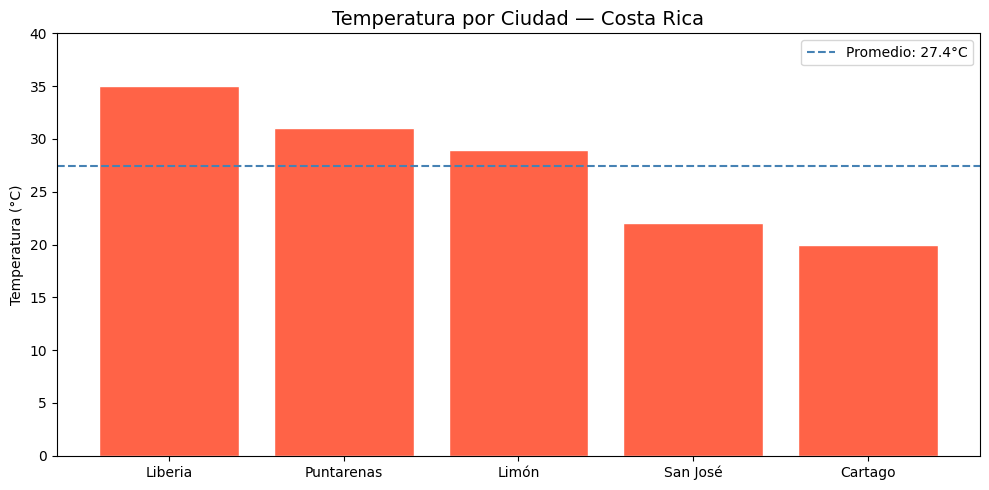

In [12]:
import matplotlib.pyplot as plt

ciudades     = ["San José", "Liberia", "Limón", "Puntarenas", "Cartago"]
temperaturas = [22,          35,        29,       31,           20]

# Ordenamos de mayor a menor temperatura usando sorted() + zip()
datos_ordenados = sorted(zip(temperaturas, ciudades), reverse=True)
temps_ord, ciu_ord = zip(*datos_ordenados)   # desempaquetamos las tuplas

# Calculamos el promedio
promedio = sum(temperaturas) / len(temperaturas)

# Graficamos
plt.figure(figsize=(10, 5))
plt.bar(ciu_ord, temps_ord, color="tomato", edgecolor="white")
plt.axhline(y=promedio, color="steelblue", linestyle="--", linewidth=1.5,
            label=f"Promedio: {promedio:.1f}°C")
plt.title("Temperatura por Ciudad — Costa Rica", fontsize=14)
plt.ylabel("Temperatura (°C)")
plt.ylim(0, max(temps_ord) + 5)
plt.legend()
plt.tight_layout()
plt.show()

### Resumen: ¿qué herramienta usamos para qué?

| Herramienta | Cuándo la usamos |
|-------------|------------------|
| `sorted(lista)` | Ordenar sin modificar la original |
| `sorted(lista, key=len)` | Ordenar por criterio personalizado |
| `sorted(lista, reverse=True)` | Ordenar de mayor a menor |
| `lista[-3:]` | Últimos N elementos (slicing con índice negativo) |
| `lista[::-1]` | Invertir la lista sin modificarla |
| `[expr for x in lista]` | Transformar cada elemento en una nueva lista |
| `[expr for x in lista if cond]` | Filtrar y transformar en una línea |
| `zip(a, b)` | Recorrer dos listas en paralelo |
| `tabla[i][j]` | Acceder a elemento en lista anidada (fila i, columna j) |

---
## ¿Qué sigue? — Semana 08

En S08 incorporamos **diccionarios** y **JSON**:

- `dict` — estructura clave-valor para representar entidades con atributos.
- `json.load()` / `json.dump()` — lectura y escritura de archivos JSON.
- Combinamos diccionarios con listas para construir estructuras de datos más expresivas.

Las comprensiones de lista que practicamos hoy tienen su equivalente en  
**comprensiones de diccionario**, que veremos también en S08.

---
*Fundamentos de Python — UMCA | Andrés Mena Abarca*